# Lab 8: Define and Solve an ML Problem of Your Choosing

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In this lab assignment, you will follow the machine learning life cycle and implement a model to solve a machine learning problem of your choosing. You will select a data set and choose a predictive problem that the data set supports.  You will then inspect the data with your problem in mind and begin to formulate a  project plan. You will then implement the machine learning project plan. 

You will complete the following tasks:

1. Build Your DataFrame
2. Define Your ML Problem
3. Perform exploratory data analysis to understand your data.
4. Define Your Project Plan
5. Implement Your Project Plan:
    * Prepare your data for your model.
    * Fit your model to the training data and evaluate your model.
    * Improve your model's performance.

## Part 1: Build Your DataFrame

You will have the option to choose one of four data sets that you have worked with in this program:

* The "census" data set that contains Census information from 1994: `censusData.csv`
* Airbnb NYC "listings" data set: `airbnbListingsData.csv`
* World Happiness Report (WHR) data set: `WHR2018Chapter2OnlineData.csv`
* Book Review data set: `bookReviewsData.csv`

Note that these are variations of the data sets that you have worked with in this program. For example, some do not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for each of the four data sets available to you.

<b>Task:</b> In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`. 

You can load each file as a new DataFrame to inspect the data before choosing your data set.

In [2]:
# File names of the four data sets
adultDataSet_filename = os.path.join(os.getcwd(), "data", "censusData.csv")
airbnbDataSet_filename = os.path.join(os.getcwd(), "data", "airbnbListingsData.csv")
WHRDataSet_filename = os.path.join(os.getcwd(), "data", "WHR2018Chapter2OnlineData.csv")
bookReviewDataSet_filename = os.path.join(os.getcwd(), "data", "bookReviewsData.csv")


df = pd.read_csv(bookReviewDataSet_filename)

df.head()

,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True


## Part 2: Define Your ML Problem

Next you will formulate your ML Problem. In the markdown cell below, answer the following questions:

1. List the data set you have chosen.
2. What will you be predicting? What is the label?
3. Is this a supervised or unsupervised learning problem? Is this a clustering, classification or regression problem? Is it a binary classificaiton or multi-class classifiction problem?
4. What are your features? (note: this list may change after your explore your data)
5. Explain why this is an important problem. In other words, how would a company create value with a model that predicts this label?

1. bookReviewDataSet
2. We will be predicting whether the review is positive or negative. The label is "Positive Review"
3. This is a supervised learning problem. This is a binary classification problem.
4. The features of our problem are the different words that make up the reviews.
5. Using our model, a company can monitor the public opinion of a product. 


## Part 3: Understand Your Data

The next step is to perform exploratory data analysis. Inspect and analyze your data set with your machine learning problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * addressing missingness, such as replacing missing values with means
    * finding and replacing outliers
    * renaming features and labels
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * performing specific data cleaning and preprocessing techniques for an NLP problem
    * addressing class imbalance in your data sample to promote fair AI
    

2. What machine learning model (or models) you would like to use that is suitable for your predictive problem and data?
    * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 
 
3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics and methods that are appropriate for your model?
    

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. If you are working on a classification problem, use techniques you have learned to determine if there is class imbalance.

<b>Task</b>: Use the techniques you have learned in this course to inspect and analyze your data. You can import additional packages that you have used in this course that you will need to perform this task.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-drown menu.

## Part 4: Define Your Project Plan

Now that you understand your data, in the markdown cell below, define your plan to implement the remaining phases of the machine learning life cycle (data preparation, modeling, evaluation) to solve your ML problem. Answer the following questions:

* Do you have a new feature list? If so, what are the features that you chose to keep and remove after inspecting the data? 
* Explain different data preparation techniques that you will use to prepare your data for modeling.
* What is your model (or models)?
* Describe your plan to train your model, analyze its performance and then improve the model. That is, describe your model building, validation and selection plan to produce a model that generalizes well to new data. 

- We will use tfidf vectorization in order to convert each of our words into features to be applied to this model
- I'll use a max features of 5000, which can be adjustable in order to find the right balance for my scores
- I'm using a simple logistic regression model for classification
- Evaluating the performance, I'll use the classification report metrics that we've been learning about and compute a confusion matrix 

## Part 5: Implement Your Project Plan

<b>Task:</b> In the code cell below, import additional packages that you have used in this course that you will need to implement your project plan.

<b>Task:</b> Use the rest of this notebook to carry out your project plan. 

You will:

1. Prepare your data for your model.
2. Fit your model to the training data and evaluate your model.
3. Improve your model's performance by performing model selection and/or feature selection techniques to find best model for your problem.

Add code cells below and populate the notebook with commentary, code, analyses, results, and figures as you see fit. 

In [13]:
!pip install nltk
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.tokenize import word_tokenize

Defaulting to user installation because normal site-packages is not writeable


[nltk_data] Downloading package punkt to /home/codio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/codio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/codio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/codio/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [14]:
lemmatizer = WordNetLemmatizer()
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return nltk.corpus.wordnet.ADJ
        elif tag.startswith('V'):
            return nltk.corpus.wordnet.VERB
        elif tag.startswith('N'):
            return nltk.corpus.wordnet.NOUN
        elif tag.startswith('R'):
            return nltk.corpus.wordnet.ADV
        else:
            return nltk.corpus.wordnet.NOUN

def lemmatize_text(text):
        tokens = word_tokenize(text)
        tagged_tokens = pos_tag(tokens)
        lemmatized_words = []
        for word, tag in tagged_tokens:
            pos = get_wordnet_pos(tag)
            lemmatized_words.append(lemmatizer.lemmatize(word, pos=pos))
        return ' '.join(lemmatized_words)
print(lemmatize_text(df["Review"][0]))



This be perhaps the best of Johannes Steinhoff 's book , since it do not deal with his own stellar yet tragic WW II and post war career . The insight of the average person living in Germany be of great importance to both social and military historian alike . Steinhoff offer this collective testament a a warning to all of u regard war and the rise of a dictator . As Johannes say in an interview , & quot ; It be always the civilian who suffer the most , yet be remember the least. & quot


[nltk_data] Downloading package wordnet to /home/codio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/codio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [15]:
df['lemmatized_Review'] = df['Review'].apply(lemmatize_text)

In [16]:
df['tokenized_lemmatized_Review'] = df['lemmatized_Review'].apply(word_tokenize)

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['lemmatized_Review']).toarray()
y = df['Positive Review']


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.84      0.85      0.84       195
        True       0.85      0.84      0.84       200

    accuracy                           0.84       395
   macro avg       0.84      0.84      0.84       395
weighted avg       0.84      0.84      0.84       395



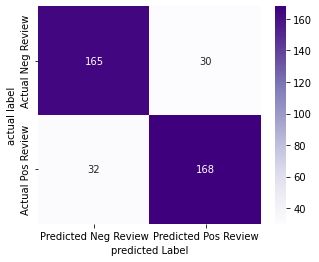

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predicted Neg Review', 'Predicted Pos Review'], 
            yticklabels=['Actual Neg Review', 'Actual Pos Review'])

plt.ylabel('actual label')
plt.xlabel('predicted Label')
plt.show()


In [35]:
y_pred = model.predict(X_test)


results_df = pd.DataFrame({
    'Review': df.loc[y_test.index, 'Review'],   
    'Actual': y_test,
    'Predicted': y_pred
})

print(results_df.head(10))
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy score: {accuracy:.2f}")

                                                 Review  Actual  Predicted
759   I forced myself to finish this book before I r...   False      False
297   Truly the author's pen is mightier than the sw...    True      False
1421  Terry's son, Nile, has honored his father (and...    True       True
350   Painstakingly compiled by Judy Brown (contribu...    True       True
1103  For the first quarter of the book, I thought E...    True       True
693   What a wonderful book. It's too bad so many re...    True      False
70    I have enjoyed many of Mark's novels (Do You K...   False      False
1422  This volume contains 152 middle length sutras ...    True       True
56    Is that those who read it and believe it, beli...   False       True
1078  Some photographers think what's erotic is what...   False      False

 Accuracy score: 0.84
